In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import os
import random
import warnings
import csv

from DCmatch import Match
warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter(action="ignore", category=UserWarning)
warnings.simplefilter("ignore", pd.errors.SettingWithCopyWarning)

folder = os.fsencode("seasons/bettingSeasons")
dataframes = []
for file in sorted(os.listdir(folder)):
    filename = os.fsdecode(file)
    if filename.endswith(".csv"):
        print(filename)
        df = pd.read_csv("seasons/bettingSeasons/" + filename)
        dataframes.append(df)

data = pd.concat(dataframes, axis=0)
data = data[[
    "Date", "HomeTeam", "AwayTeam", "FTHG", "FTAG", "FTR", "MaxH", "MaxD", "MaxA"
]]

uniqueTeams = data["HomeTeam"].unique()
teamsIndex = {}
for i in range(len(uniqueTeams)):
    teamsIndex[uniqueTeams[i]] = i

teamsLookup = {v: k for k, v in teamsIndex.items()}

newEstimates = []

with open("newEstimatesOvernight.csv", newline="") as my_csv:
    csvReader = csv.reader(my_csv)
    for row in csvReader:
        newEstimates.append([float(x) for x in row])

strengthsOverTime = [[row[i] for row in newEstimates] for i in range(len(newEstimates[0]))]

1920-Copy1.csv
2021-Copy1.csv
2122-Copy1.csv
2223-Copy1.csv
2324-Copy1.csv
2425-Copy1.csv
E0 (1).csv


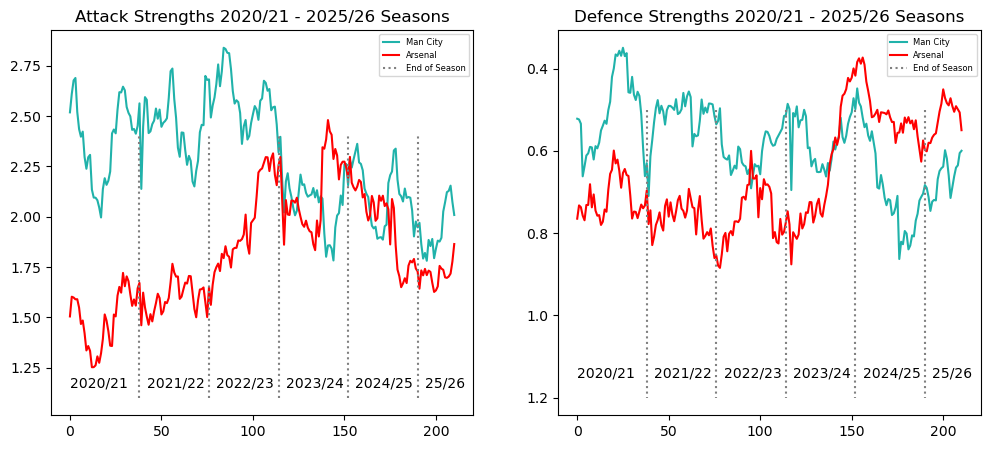

In [67]:
teamsLookup = {v: k for k, v in teamsIndex.items()}

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(strengthsOverTime[teamsIndex.get("Man City")], label="Man City", color="lightseagreen")
ax[0].plot(strengthsOverTime[teamsIndex.get("Arsenal")], label="Arsenal", color="red")
ax[0].set_title("Attack Strengths 2020/21 - 2025/26 Seasons")
ax[0].vlines(38, 1.1, 2.4, color="grey", linestyle="dotted", label="End of Season")
ax[0].vlines(76, 1.1, 2.4, color="grey", linestyle="dotted")
ax[0].vlines(114, 1.1, 2.4, color="grey", linestyle="dotted")
ax[0].vlines(152, 1.1, 2.4, color="grey", linestyle="dotted")
ax[0].vlines(190, 1.1, 2.4, color="grey", linestyle="dotted")
ax[0].legend(prop={'size': 6})
ax[0].text(0, 1.15, "2020/21")
ax[0].text(42, 1.15, "2021/22")
ax[0].text(80, 1.15, "2022/23")
ax[0].text(118, 1.15, "2023/24")
ax[0].text(156, 1.15, "2024/25")
ax[0].text(194, 1.15, "25/26")

ax[1].plot(strengthsOverTime[teamsIndex.get("Man City")+28], label="Man City", color="lightseagreen")
ax[1].plot(strengthsOverTime[teamsIndex.get("Arsenal")+28], label="Arsenal", color="red")
ax[1].set_title("Defence Strengths 2020/21 - 2025/26 Seasons")
ax[1].invert_yaxis()
ax[1].vlines(38, 0.5, 1.2, color="grey", linestyle="dotted", label="End of Season")
ax[1].vlines(76, 0.5, 1.2, color="grey", linestyle="dotted")
ax[1].vlines(114, 0.5, 1.2, color="grey", linestyle="dotted")
ax[1].vlines(152, 0.5, 1.2, color="grey", linestyle="dotted")
ax[1].vlines(190, 0.5, 1.2, color="grey", linestyle="dotted")
ax[1].legend(prop={'size': 6})
ax[1].text(0, 1.15, "2020/21")
ax[1].text(42, 1.15, "2021/22")
ax[1].text(80, 1.15, "2022/23")
ax[1].text(118, 1.15, "2023/24")
ax[1].text(156, 1.15, "2024/25")
ax[1].text(194, 1.15, "25/26")
fig.savefig("top3.jpg")

In [7]:
teamStrengths = [[] for i in range(58)]

for i in range(len(data["AwayTeam"])):
    if i < 380:
        for j in range(58):
            teamStrengths[j].append(0)
    else:
        for j in range(58):
            teamStrengths[j].append(strengthsOverTime[j][(i-380) // 10])

attack = teamStrengths[0:28]
defence = teamStrengths[28:56]
homeAdvantage = teamStrengths[-2]
rho = teamStrengths[-1]
home_idx = data["HomeTeam"].map(teamsIndex).to_numpy()
away_idx = data["AwayTeam"].map(teamsIndex).to_numpy()
t = np.arange(len(data["HomeTeam"]))

homeAttacks = []
homeDefences = []
awayAttacks = []
awayDefences = []

for i in range(len(data["HomeTeam"])):
    homeAttacks.append(attack[home_idx[i]][i])
    homeDefences.append(defence[home_idx[i]][i])
    awayAttacks.append(attack[away_idx[i]][i])
    awayDefences.append(defence[away_idx[i]][i])

homeProbs = []
drawProbs = []
awayProbs = []

for i in range(len(data["HomeTeam"])):
    thisMatch = Match(homeAttacks[i], homeDefences[i], awayAttacks[i], awayDefences[i], homeAdvantage[i], rho[i], 8)
    outcomes = thisMatch.getOutcomeProbs()
    homeProbs.append(outcomes[0])
    drawProbs.append(outcomes[1])
    awayProbs.append(outcomes[2])



data["attackH"]  = homeAttacks
data["defenceH"] = homeDefences
data["attackA"]  = awayAttacks
data["defenceA"] = awayDefences
data["rho"] = rho
data["homeAdv"] = homeAdvantage
data["homeProb"] = homeProbs
data["drawProb"] = drawProbs
data["awayProb"] = awayProbs
data["FairHomeOdds"] = 1 / data["homeProb"]
data["FairDrawOdds"] = 1 / data["drawProb"]
data["FairAwayOdds"] = 1 / data["awayProb"]

In [9]:
bettingFrame = data.tail(n=2110)
bettingFrame["HomeWin"] = np.where(bettingFrame["FTR"] == "H", 1, 0)
bettingFrame["Draw"] = np.where(bettingFrame["FTR"] == "D", 1, 0)
bettingFrame["AwayWin"] = np.where(bettingFrame["FTR"] == "A", 1, 0)
bettingFrame.head()

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,MaxH,MaxD,MaxA,attackH,...,homeAdv,homeProb,drawProb,awayProb,FairHomeOdds,FairDrawOdds,FairAwayOdds,HomeWin,Draw,AwayWin
0,12/09/2020,Fulham,Arsenal,0,3,A,6.55,4.55,1.60,1.077867,...,1.342738,0.256029,0.272854,0.471117,3.905806,3.664968,2.122614,0,0,1
1,12/09/2020,Crystal Palace,Southampton,1,0,H,3.36,3.36,2.50,0.725293,...,1.342738,0.237064,0.303230,0.459706,4.218275,3.297823,2.175303,1,0,0
2,12/09/2020,Liverpool,Leeds,4,3,H,1.35,6.50,10.75,2.010702,...,1.342738,0.676324,0.195212,0.128464,1.478581,5.122624,7.784309,1,0,0
3,12/09/2020,West Ham,Newcastle,0,2,A,2.24,3.70,3.60,1.332293,...,1.342738,0.559395,0.244834,0.195771,1.787646,4.084399,5.108004,0,0,1
4,13/09/2020,West Brom,Leicester,0,3,A,4.00,3.82,2.04,0.999085,...,1.342738,0.274875,0.282907,0.442218,3.638018,3.534736,2.261326,0,0,1


In [25]:
bettingFrame["ValueRatioHome"] = bettingFrame["MaxH"] * bettingFrame["homeProb"]
bettingFrame["ValueRatioDraw"] = bettingFrame["MaxD"] * bettingFrame["drawProb"]
bettingFrame["ValueRatioAway"] = bettingFrame["MaxA"] * bettingFrame["awayProb"]

threshold = 1

value_cols = ['ValueRatioHome', 'ValueRatioAway', 'ValueRatioDraw']

# Identify best outcome per row
best = bettingFrame[value_cols].idxmax(axis=1)
max_value = bettingFrame[value_cols].max(axis=1)

# Reset bets
bettingFrame[['HomeBet', 'AwayBet', 'DrawBet']] = 0

bettingFrame.loc[
    (max_value > threshold) & (best == 'ValueRatioHome'),
    'HomeBet'
] = 1

bettingFrame.loc[
    (max_value > threshold) & (best == 'ValueRatioAway'),
    'AwayBet'
] = 1

bettingFrame.loc[
    (max_value > threshold) & (best == 'ValueRatioDraw'),
    'DrawBet'
] = 1

bettingFrame["flatProfit"] = bettingFrame["HomeWin"] * bettingFrame["HomeBet"] * bettingFrame["MaxH"] + bettingFrame["AwayWin"] * bettingFrame["AwayBet"] * bettingFrame["MaxA"] + bettingFrame["Draw"] * bettingFrame["DrawBet"] * bettingFrame["MaxD"] - (bettingFrame["HomeBet"] + bettingFrame["AwayBet"] + bettingFrame["DrawBet"])
bettingFrame["betOnHomeTeam"] = bettingFrame["HomeWin"] * bettingFrame["MaxH"] - 1

In [15]:
dates = pd.to_datetime(data["Date"], format="%d/%m/%Y")
data["Week"] = (
    dates.dt.day
    + dates.dt.month * 12
    + dates.dt.year * 365
) // 7

In [31]:
bettingFrame["FavOdds"] = bettingFrame[["MaxH", "MaxD", "MaxA"]].min(axis=1)
bettingFrame["Favourite"] = bettingFrame[["MaxH", "MaxD", "MaxA"]].idxmin(axis=1)
bettingFrame["FavHomeBet"] = (bettingFrame["Favourite"] == "MaxH").astype(int)
bettingFrame["FavDrawBet"] = (bettingFrame["Favourite"] == "MaxD").astype(int)
bettingFrame["FavAwayBet"] = (bettingFrame["Favourite"] == "MaxA").astype(int)
bettingFrame["flatProfitFavourite"] = (
    bettingFrame["HomeWin"] * bettingFrame["FavHomeBet"] * bettingFrame["MaxH"]
  + bettingFrame["Draw"]    * bettingFrame["FavDrawBet"] * bettingFrame["MaxD"]
  + bettingFrame["AwayWin"] * bettingFrame["FavAwayBet"] * bettingFrame["MaxA"]
  - (bettingFrame["FavHomeBet"] + bettingFrame["FavDrawBet"] + bettingFrame["FavAwayBet"])
)

In [37]:
bettingFrame["HistHomeBet"] = (bettingFrame["MaxH"] > (1/0.434)).astype(int)
bettingFrame["HistDrawBet"] = (bettingFrame["MaxD"] > (1/0.231)).astype(int)
bettingFrame["HistAwayBet"] = (bettingFrame["MaxA"] > (1/0.335)).astype(int)

bettingFrame["histProfit"] = (
    bettingFrame["HomeWin"] * bettingFrame["HistHomeBet"] * bettingFrame["MaxH"]
  + bettingFrame["Draw"]    * bettingFrame["HistDrawBet"] * bettingFrame["MaxD"]
  + bettingFrame["AwayWin"] * bettingFrame["HistAwayBet"] * bettingFrame["MaxA"]
  - (bettingFrame["HistHomeBet"] + bettingFrame["HistDrawBet"] + bettingFrame["HistAwayBet"])
)

In [45]:
import numpy as np

rng = np.random.default_rng(seed=41)

bettingFrame["RandomChoice"] = rng.choice(
    ["H", "D", "A"],
    size=len(bettingFrame)
)
bettingFrame["RandomHomeBet"] = (bettingFrame["RandomChoice"] == "H").astype(int)
bettingFrame["RandomDrawBet"] = (bettingFrame["RandomChoice"] == "D").astype(int)
bettingFrame["RandomAwayBet"] = (bettingFrame["RandomChoice"] == "A").astype(int)
bettingFrame["flatProfitRandom"] = (
    bettingFrame["HomeWin"] * bettingFrame["RandomHomeBet"] * bettingFrame["MaxH"]
  + bettingFrame["Draw"]    * bettingFrame["RandomDrawBet"] * bettingFrame["MaxD"]
  + bettingFrame["AwayWin"] * bettingFrame["RandomAwayBet"] * bettingFrame["MaxA"]
  - (bettingFrame["RandomHomeBet"]
     + bettingFrame["RandomDrawBet"]
     + bettingFrame["RandomAwayBet"])
)

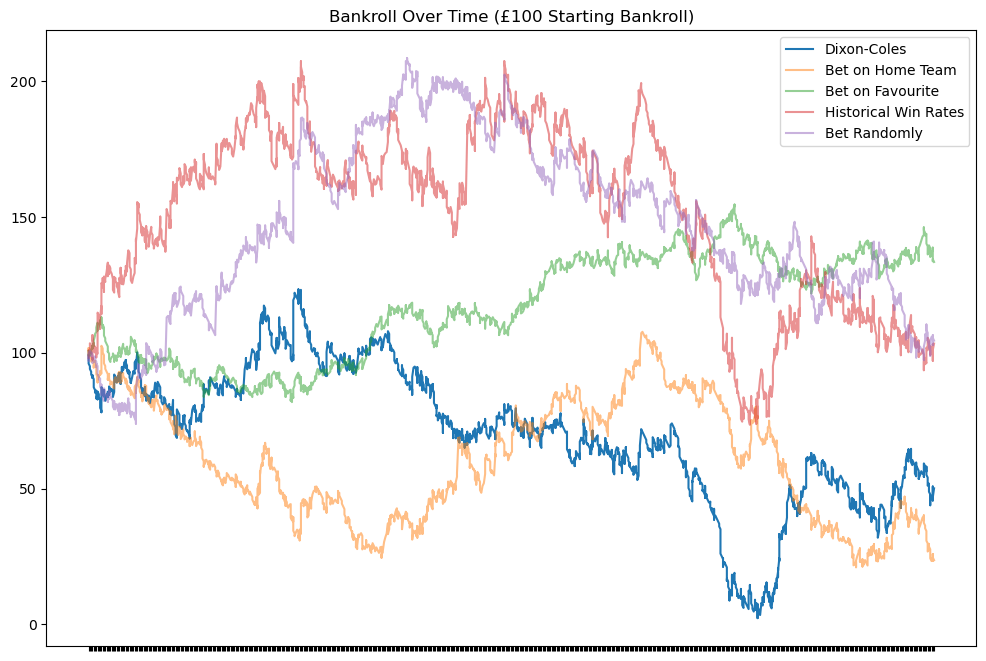

In [61]:
fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(bettingFrame.Date, bettingFrame["flatProfit"].cumsum()+100, label="Dixon-Coles")
ax.plot(bettingFrame.Date, bettingFrame["betOnHomeTeam"].cumsum()+100, label="Bet on Home Team", alpha=0.5)
ax.plot(bettingFrame.Date, bettingFrame["flatProfitFavourite"].cumsum()+100, label="Bet on Favourite", alpha=0.5)
ax.plot(bettingFrame.Date, bettingFrame["histProfit"].cumsum()+100, label="Historical Win Rates", alpha=0.5)
ax.plot(bettingFrame.Date, bettingFrame["flatProfitRandom"].cumsum()+100, label="Bet Randomly", alpha=0.5)
ax.set_title("Bankroll Over Time (£100 Starting Bankroll)")
plt.gca().set_xticklabels([])
ax.legend()

fig.savefig("bets.jpg")

In [29]:
bettingFrame.columns

Index(['Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'MaxH', 'MaxD',
       'MaxA', 'attackH', 'defenceH', 'attackA', 'defenceA', 'rho', 'homeAdv',
       'homeProb', 'drawProb', 'awayProb', 'FairHomeOdds', 'FairDrawOdds',
       'FairAwayOdds', 'HomeWin', 'Draw', 'AwayWin', 'ValueRatioHome',
       'ValueRatioDraw', 'ValueRatioAway', 'HomeBet', 'AwayBet', 'DrawBet',
       'flatProfit', 'betOnHomeTeam'],
      dtype='object')